In [1]:
!pip install numpy matplotlib
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# draw a 2D function
def draw_2d_function(ax, x1_mesh, x2_mesh, y):
    pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256, cmap='hot', vmin=-10, v_max=10)
    ax.set_xlabel('x1'); ax.set_ylabel('x2')
    levels = np.arange(-10, 10, 1.0)
    ax.contour(x1_mesh, x2_mesh, y, levels, cmap='winter')

# plot the NN.
# assume input range [0,10], [0,10] and outputt [-10, 10]
def plot_neural_2_inputs(x1, x2, y,
                         pre_1, pre_2, pre_3,
                         act_1, act_2, act_3,
                         w_act_1, w_act_2, w_act_3):
    fig, ax = plt.subplots(3, 3)
    fig.set_size_inches(10, 10)
    fig.tight_layout(pad=3.0)
    draw_2d_function(ax[0, 0], x1, x2, pre_1); ax[0, 0].set_title('preactivation')
    draw_2d_function(ax[0, 1], x1, x2, pre_2); ax[0, 1].set_title('preactivation')
    draw_2d_function(ax[0, 2], x1, x2, pre_3); ax[0, 2].set_title('preactivation')

    draw_2d_function(ax[1, 0], x1, x2, act_1); ax[1, 0].set_title('activation')
    draw_2d_function(ax[1, 1], x1, x2, act_2); ax[1, 1].set_title('activation')
    draw_2d_function(ax[1, 2], x1, x2, act_3); ax[1, 2].set_title('activation')

    draw_2d_function(ax[2, 0], x1, x2, w_act_1); ax[2, 0].set_title('weighted activation')
    draw_2d_function(ax[2, 1], x1, x2, w_act_2); ax[2, 1].set_title('weighted activation')
    draw_2d_function(ax[2, 2], x1, x2, w_act_3); ax[2, 2].set_title('weighted activation')
    plt.show()

    fig, ax = plt.subplots()
    draw_2d_function(ax, x1, x2, y)
    ax.set_title('Network outputs')
    ax.set_aspect(1.0)
    plt.show()

In [3]:
def ReLU(preactivation):
    activation = np.clip(preactivation, 0, np.inf)
    return activation

In [7]:
# shallow NN with 2 input, 1 output, 3 hidden
def shallow_2_1_3(x1, x2, activation_fn,
                  phi_0, phi_1, phi_2, phi_3,
                  theta_10, theta_11, theta_12,
                  theta_20, theta_21, theta_22,
                  theta_30, theta_31, theta_32):
    pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
    pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
    pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    w_act_1 = phi_1 * act_1
    w_act_2 = phi_2 * act_2
    w_act_3 = phi_3 * act_3

    y = phi_0 + w_act_1 + w_act_2 + w_act_3

    return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

/tmp/ipykernel_5968/1021687153.py:3: UserWarning: The following kwargs were not used by contour: 'v_max'
  pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256, cmap='hot', vmin=-10, v_max=10)


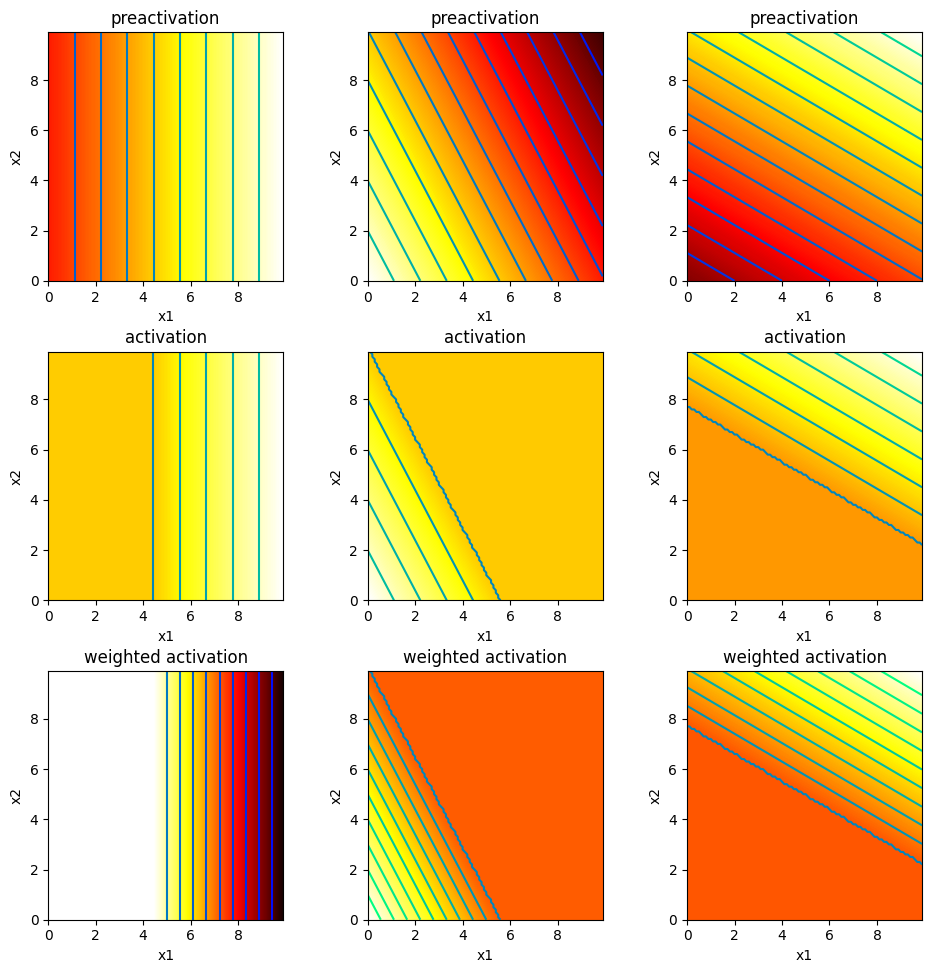

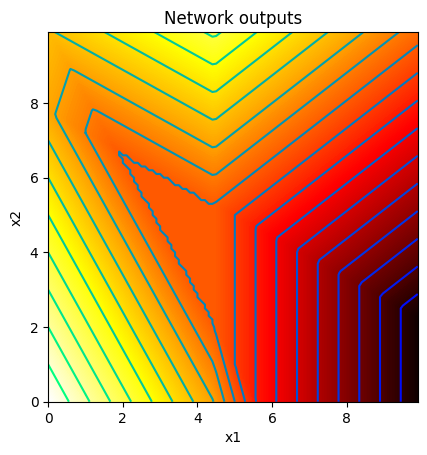

In [8]:
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_0 = 0.0; phi_1 = -2.0; phi_2 = 2.0; phi_3 = 1.5

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1, x2 = np.meshgrid(x1, x2)

y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3 = \
    shallow_2_1_3(x1, x2, ReLU, \
                  phi_0, phi_1, phi_2, phi_3, \
                  theta_10, theta_11, theta_12, \
                  theta_20, theta_21, theta_22, \
                  theta_30, theta_31, theta_32)

plot_neural_2_inputs(x1,x2, y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3)

In [16]:
def plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23):

  # Plot intermediate plots if flag set
  fig, ax = plt.subplots(4,3)
  fig.set_size_inches(10, 10)
  fig.tight_layout(pad=3.0)
  draw_2d_function(ax[0,0], x1,x2,pre_1); ax[0,0].set_title('Preactivation')
  draw_2d_function(ax[0,1], x1,x2,pre_2); ax[0,1].set_title('Preactivation')
  draw_2d_function(ax[0,2], x1,x2,pre_3); ax[0,2].set_title('Preactivation')
  draw_2d_function(ax[1,0], x1,x2,act_1); ax[1,0].set_title('Activation')
  draw_2d_function(ax[1,1], x1,x2,act_2); ax[1,1].set_title('Activation')
  draw_2d_function(ax[1,2], x1,x2,act_3); ax[1,2].set_title('Activation')
  draw_2d_function(ax[2,0], x1,x2,w_act_11); ax[2,0].set_title('Weighted Act 1')
  draw_2d_function(ax[2,1], x1,x2,w_act_12); ax[2,1].set_title('Weighted Act 1')
  draw_2d_function(ax[2,2], x1,x2,w_act_13); ax[2,2].set_title('Weighted Act 1')
  draw_2d_function(ax[3,0], x1,x2,w_act_21); ax[3,0].set_title('Weighted Act 2')
  draw_2d_function(ax[3,1], x1,x2,w_act_22); ax[3,1].set_title('Weighted Act 2')
  draw_2d_function(ax[3,2], x1,x2,w_act_23); ax[3,2].set_title('Weighted Act 2')
  plt.show()

  fig, ax = plt.subplots()
  draw_2d_function(ax,x1,x2,y1)
  ax.set_title('Network output, y1')
  ax.set_aspect(1.0)
  plt.show()

  fig, ax = plt.subplots()
  draw_2d_function(ax,x1,x2,y2)
  ax.set_title('Network output, y2')
  ax.set_aspect(1.0)
  plt.show()

In [17]:
def shallow_2_2_3(x1, x2, activation_fn,
                  phi_10, phi_11, phi_12, phi_13,
                  phi_20, phi_21, phi_22, phi_23,
                  theta_10, theta_11, theta_12,
                  theta_20, theta_21, theta_22,
                  theta_30, theta_31, theta_32):
    pre_1 = theta_10 + theta_11 * x1 + theta_12 * x2
    pre_2 = theta_20 + theta_21 * x1 + theta_22 * x2
    pre_3 = theta_30 + theta_31 * x1 + theta_32 * x2

    act_1 = activation_fn(pre_1)
    act_2 = activation_fn(pre_2)
    act_3 = activation_fn(pre_3)

    w_act_11 = phi_11 * act_1
    w_act_12 = phi_12 * act_2
    w_act_13 = phi_13 * act_3
    w_act_21 = phi_21 * act_1
    w_act_22 = phi_22 * act_2
    w_act_23 = phi_23 * act_3

    y1 = phi_10 + w_act_11 + w_act_12 + w_act_13
    y2 = phi_20 + w_act_21 + w_act_22 + w_act_23

    return y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23

/tmp/ipykernel_5968/1021687153.py:3: UserWarning: The following kwargs were not used by contour: 'v_max'
  pos = ax.contourf(x1_mesh, x2_mesh, y, levels=256, cmap='hot', vmin=-10, v_max=10)


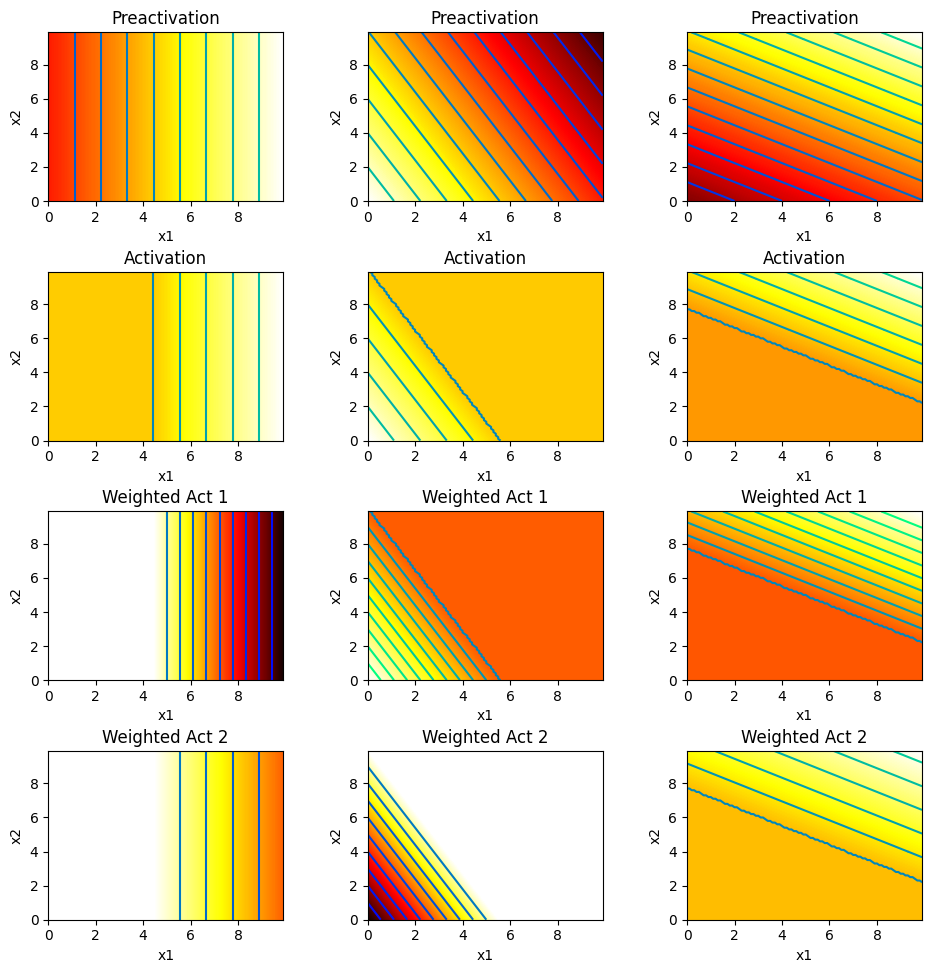

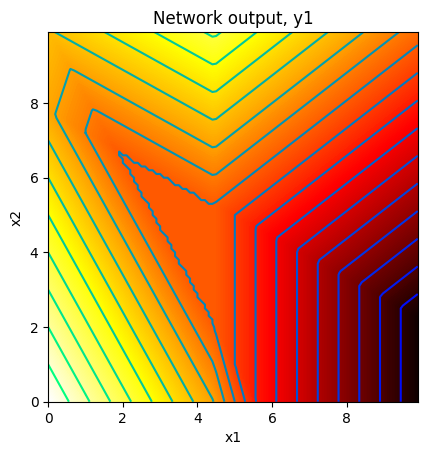

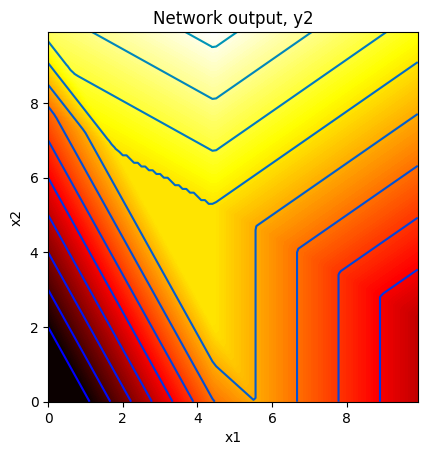

In [18]:
theta_10 =  -4.0 ;  theta_11 = 0.9; theta_12 = 0.0
theta_20 =  5.0  ; theta_21 = -0.9 ; theta_22 = -0.5
theta_30 =  -7  ; theta_31 = 0.5; theta_32 = 0.9
phi_10 = 0.0; phi_11 = -2.0; phi_12 = 2.0; phi_13 = 1.5
phi_20 = -2.0; phi_21 = -1.0; phi_22 = -2.0; phi_23 = 0.8

x1 = np.arange(0.0, 10.0, 0.1)
x2 = np.arange(0.0, 10.0, 0.1)
x1,x2 = np.meshgrid(x1,x2)

y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23 = \
    shallow_2_2_3(x1,x2, ReLU, phi_10,phi_11,phi_12,phi_13, phi_20,phi_21,phi_22,phi_23, theta_10, theta_11, theta_12, theta_20, theta_21, theta_22, theta_30, theta_31, theta_32)

plot_neural_2_inputs_2_outputs(x1,x2, y1, y2, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_11, w_act_12, w_act_13, w_act_21, w_act_22, w_act_23)